# Bibliotecas

In [44]:
from obj import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregando dados de vigas

In [45]:
# ==================================
# LEITURA DO DATASET
# ==================================

file_path = r'final_df_tempo_limite.xlsx'
full_df = pd.read_excel(file_path)

# Seleciona apenas a primeira linha para análise de teste
df = full_df.head(1)
print(df)


    b_w    h   f_ck      m_rd      m_gk      m_qk       a_s       time
0  0.14  0.3  20000  9.836582  6.323517  0.702613  0.000076  50.621397


# Dados para análise de vida útil

In [46]:
# ==================================
# PARÂMETROS GERAIS DO MODELO
# ==================================

# Número de simulações Monte Carlo
n_simul = 1000

# Tempos de análise (anos)
tempos = np.arange(0, 101, 5)

# Cobrimento das armaduras (mm)
cob = 25

# Módulo de elasticidade do aço (kPa)
e_s = 200E3

# Progressão da carbonatação (mm/ano^0.5)
prog_y = 6

# Coeficientes de Monte Carlo
f_yk_default = 500E3  # kPa


In [47]:
# ============================================
# Modelo preditivo de degradação e confiabilidade
# ============================================

# Inicialização das listas para armazenamento dos resultados globais
results_mr = []   # Momentos resistentes (kN·m)
results_ms = []   # Momentos solicitantes (kN·m)
results_as = []   # Áreas de aço (cm² ou adimensional, conforme definição)
results_g  = []   # Margens de segurança (kN·m)
t_sem_cor  = []   # Tempos sem corrosão (anos)

# Loop principal: percorre cada linha do DataFrame de entrada
for i, row in df.iterrows():

    # -----------------------------
    # Extração dos parâmetros de entrada
    # -----------------------------
    b_w = row['b_w']         # Largura da seção (cm)
    h = row['h']             # Altura da seção (cm)
    f_ck = row['f_ck']       # Resistência característica do concreto (kPa)
    f_yk = 500E3             # Resistência característica do aço (kPa)
    m_gk = row['m_gk']       # Momento de carga permanente (N·cm)
    m_qk = row['m_qk']       # Momento de carga variável (N·cm)
    a_s_initial = row['a_s'] # Área inicial de aço (cm²)

# ==================================
# SIMULAÇÃO MONTE CARLO - DEGRADAÇÃO DA ÁREA DE AÇO
# ==================================

# Inicialização das listas para armazenar resultados
results_mr = []   # Momentos resistentes
results_ms = []   # Momentos solicitantes (m_g + m_q)
results_as = []   # Áreas de aço ao longo do tempo
results_g = []    # Função de estado g

# Loop sobre cada linha do DataFrame
for i, row in df.iterrows():
    # Parâmetros da seção
    b_w = row['b_w']            # largura da seção (cm)
    h = row['h']                # altura da seção (cm)
    f_ck = row['f_ck']          # resistência característica do concreto (kPa)
    f_yk = 500E3                # resistência característica do aço (kPa)
    m_gk = row['m_gk']          # momento devido a cargas permanentes (N·cm)
    m_qk = row['m_qk']          # momento devido a cargas variáveis (N·cm)
    a_s_initial = row['a_s']    # área inicial de aço (cm²)

    # Simulações de Monte Carlo
    for j in range(n_simul):
        m_r_list = []  # momentos resistentes
        a_s_list = []  # áreas de aço
        m_s_list = []  # momentos solicitantes
        g_list = []    # função de estado

        # Amostras das variáveis aleatórias
        f_ck_sample = np.random.normal(1.22 * f_ck, 0.12 * 1.22 * f_ck)
        f_yk_sample = np.random.normal(1.22 * f_yk, 0.05 * 1.22 * f_yk)
        m_gk_sample = np.random.normal(1.06 * m_gk, 0.12 * 1.06 * m_gk)
        relacao_d_h = np.random.uniform(0.8, 0.9)
        i_corr_20 = max(np.random.normal(0.431, 0.259), 1e-5)  # índice de corrosão mínimo positivo

        # Loop sobre os passos de tempo
        for k in tempos:
            # Amostra do momento variável e temperatura ambiente
            m_qk_sample = np.random.gumbel(0.21 * m_qk, 0.21 * 0.76 * m_qk)
            temp = np.random.uniform(20, 30)
            d_barras = 12.5 / 1000  # diâmetro da barra (m)
            n_barras = a_s_initial / (np.pi * d_barras**2 / 4)
            y_carb = prog_y * k**0.5  # profundidade de carbonatação (mm)

            # Cálculo da área de aço degradada
            if y_carb <= cob:
                # Sem corrosão: área original
                a_s_calculada = a_s_initial
                m_rd = momento_limite_armadura_simples(
                    a_s_calculada, b_w, h, relacao_d_h, f_ck_sample, f_yk_sample, e_s
                )
            else:
                # Com corrosão: área reduzida pelo modelo de Azad & Algohi
                t_iniciacao = tempos[0]  # ou tempo de início da corrosão
                m_rd, c_f, d_novo, a_s_calculada = momento_resistente_com_corrosao_azad_algohi(
                    d_barras, n_barras, f_ck_sample, f_yk_sample, e_s,
                    b_w, h, relacao_d_h, i_corr_20, temp, k, t_iniciacao
                )

            # Armazenar resultados
            m_r_list.append(m_rd)
            a_s_list.append(a_s_calculada)
            m_s_list.append(m_gk_sample + m_qk_sample)
            g_list.append(m_rd - (m_gk_sample + m_qk_sample))

        # Adicionar resultados da simulação às listas principais
        results_mr.append(m_r_list)
        results_as.append(a_s_list)
        results_ms.append(m_s_list)
        results_g.append(g_list)

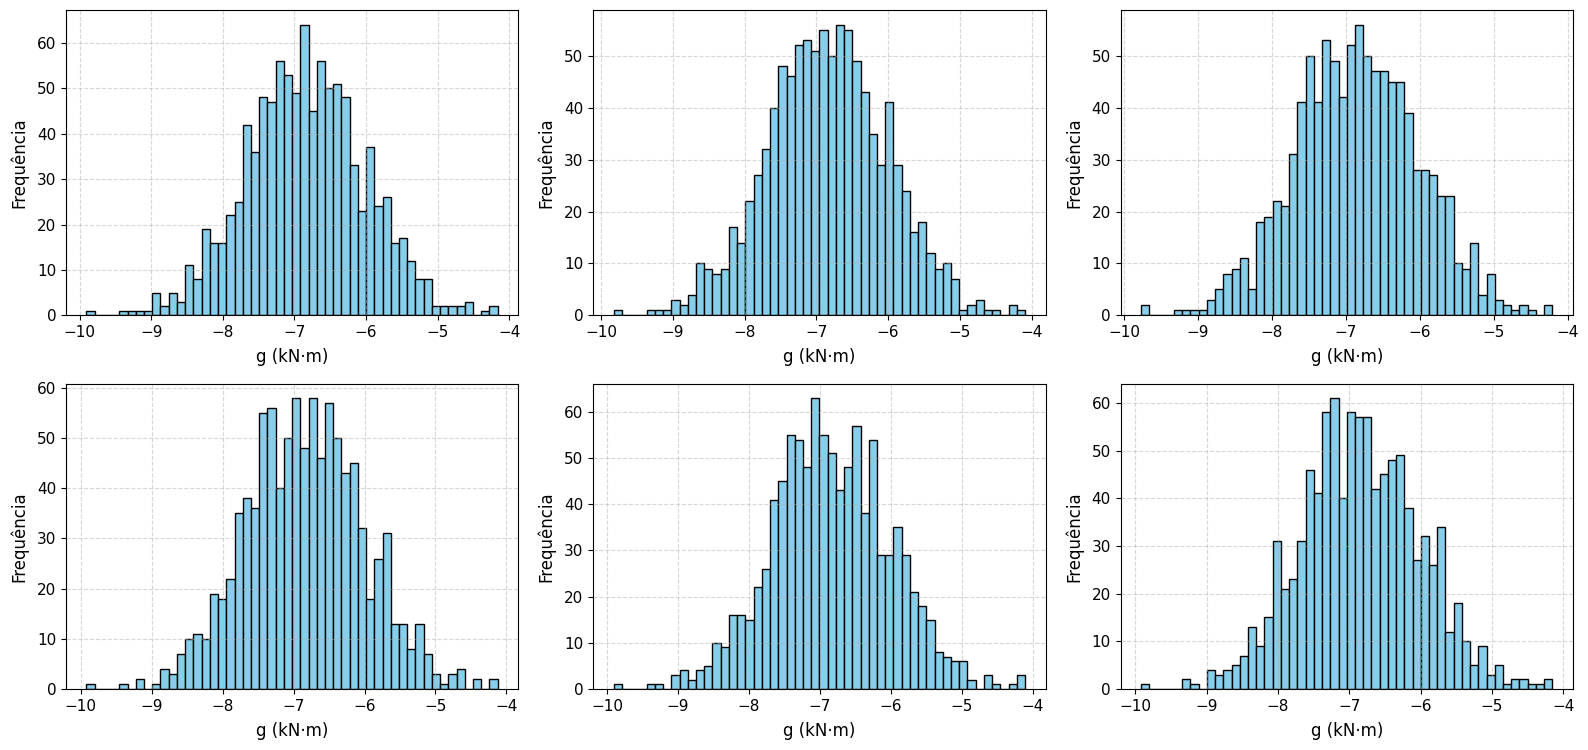

In [48]:
# ================================================================
# Análise estatística e visualização dos resultados da simulação
# ================================================================

# Lista com os tempos correspondentes aos índices de cada valor em g_list
times = [0, 20, 40, 60, 80, 100]

# Criação de um dicionário para armazenar os valores de g (m_r - m_gk - m_qk)
# separados por tempo de análise
t_dict = {time: [] for time in times}

# Itera sobre cada simulação e organiza os resultados por tempo
for g_list in results_g:
    for idx, time in enumerate(times):
        t_dict[time].append(g_list[idx])

# Criação de listas separadas para cada tempo (facilita manipulação posterior)
t_0   = t_dict[0]
t_20  = t_dict[20]
t_40  = t_dict[40]
t_60  = t_dict[60]
t_80  = t_dict[80]
t_100 = t_dict[100]

# Agrupamento das listas principais para iteração conjunta nos gráficos
t_lists = [t_0, t_20, t_40, t_60, t_80, t_100]

# ================================================================
# Geração dos histogramas de distribuição para cada tempo analisado
# ================================================================

# Criação da figura e dos eixos para 6 subplots (2 linhas x 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Ajuste do espaçamento entre subplots
plt.subplots_adjust(wspace=0.25, hspace=0.3)

# Loop de plotagem: um histograma para cada tempo de exposição
for idx, (t_values, time) in enumerate(zip(t_lists, times)):
    ax = axes[idx // 3, idx % 3]  # Define a posição do subplot (linha, coluna)

    # Histograma
    ax.hist(t_values, bins=50, color='skyblue', edgecolor='black')

    # Ajuste do tamanho e fonte dos eixos
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.tick_params(axis='both', which='minor', labelsize=9)

    # Rótulos dos eixos com fonte ajustada
    ax.set_xlabel('g (kN·m)', fontsize=12, labelpad=6)
    ax.set_ylabel('Frequência', fontsize=12, labelpad=6)

    # Grade sutil para melhor leitura
    ax.grid(True, linestyle='--', alpha=0.5)

# Layout final e exibição
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [77]:
# ===============================
# CONFIGURAÇÕES DE TAMANHO E ESTILO DO GRÁFICO
# ===============================
config_grafico = {
    "figsize": (8, 5),        # Tamanho da figura (largura x altura)
    "fonte_label": 13,        # Tamanho da fonte dos labels
    "fonte_tick": 11,      # Tamanho dos números nos eixos
    "line_width": 1.5,        # Espessura das linhas
    "alpha_curva": 0.3,       # Transparência das curvas
    "marker_size": 3,         # Tamanho dos marcadores
    "dpi": 600,               # Resolução para salvar
    "cor_curva": "gray",      # Cor das curvas
    "cor_vertical": "red",
}

GRÁFICO DO MOMENTO RESISTENTE

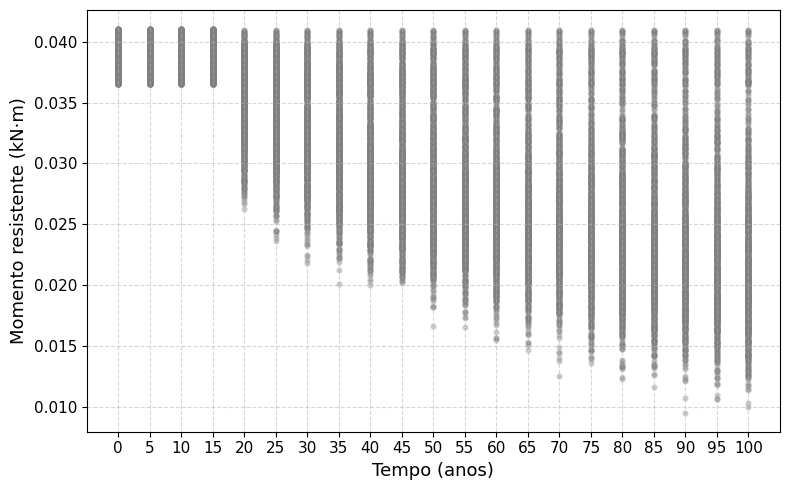

In [50]:
# ===============================
# PLOTAGEM DAS CURVAS DE MOMENTO RESISTENTE
# ===============================
plt.figure(figsize=config_grafico["figsize"])

for m_r_curve in results_mr:
    plt.scatter(
        tempos, 
        m_r_curve,
        marker='o',
        linestyle='-',
        color=config_grafico["color"],
        alpha=config_grafico["alpha"],
        s=config_grafico["marker_size"]**2,  # Matplotlib usa área para o tamanho do scatter
        linewidth=config_grafico["line_width"]
    )

# Configuração dos eixos com títulos
plt.xlabel("Tempo (anos)", fontsize=config_grafico["label_fontsize"])
plt.ylabel("Momento resistente (kN·m)", fontsize=config_grafico["label_fontsize"])
plt.tick_params(axis='both', which='major', labelsize=config_grafico["tick_fontsize"])

# Grade e layout
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(tempos)
plt.tight_layout()

# Salvamento em alta resolução
plt.savefig('moment_cap_curves.png', dpi=config_grafico["dpi"], bbox_inches='tight')

# Exibir o gráfico
plt.show()

GRÁFICO DO MOMENTO SOLICITANTE

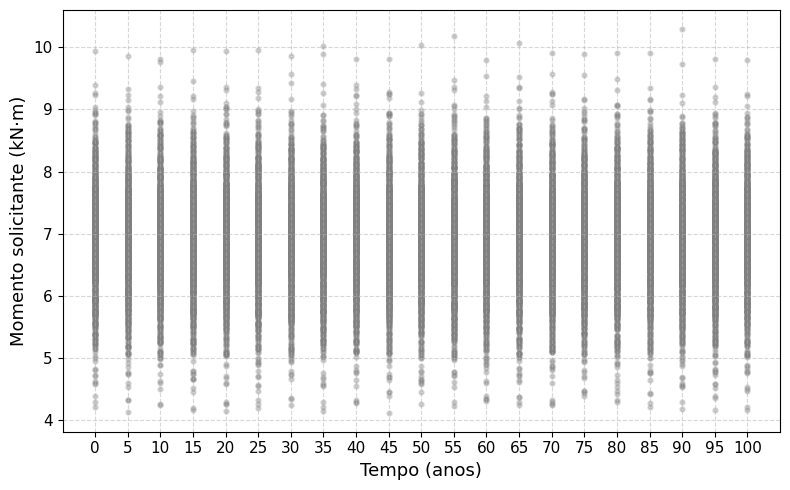

In [51]:
# ===============================
# PLOTAGEM DAS CURVAS DE MOMENTO SOLICITANTE
# ===============================
plt.figure(figsize=config_grafico["figsize"])

for m_s_curve in results_ms:
    plt.scatter(
        tempos, 
        m_s_curve,
        marker='o',
        linestyle='-',
        color=config_grafico["color"],
        alpha=config_grafico["alpha"],
        s=config_grafico["marker_size"]**2,  # Matplotlib usa área para o tamanho do scatter
        linewidth=config_grafico["line_width"]
    )

# Configuração dos eixos com títulos
plt.xlabel("Tempo (anos)", fontsize=config_grafico["label_fontsize"])
plt.ylabel("Momento solicitante (kN·m)", fontsize=config_grafico["label_fontsize"])
plt.tick_params(axis='both', which='major', labelsize=config_grafico["tick_fontsize"])

# Grade e layout
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(tempos)
plt.tight_layout()

# Salvamento em alta resolução
plt.savefig('curvas_momento_solicitante.png', dpi=config_grafico["dpi"], bbox_inches='tight')

# Exibir o gráfico
plt.show()

FUNÇÃO DE ESTADO g

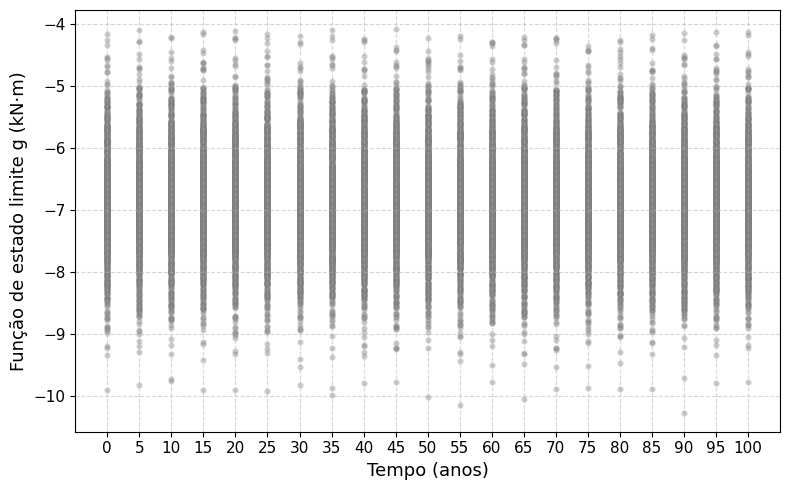

In [52]:
# ===============================
# PLOTAGEM DAS CURVAS DA FUNÇÃO ESTADO LIMITE (g)
# ===============================
plt.figure(figsize=config_grafico["figsize"])

for g_curve in results_g:
    plt.scatter(
        tempos,
        g_curve,
        marker='o',
        linestyle='-',
        color=config_grafico["color"],
        alpha=config_grafico["alpha"],
        s=config_grafico["marker_size"]**2,
        linewidth=config_grafico["line_width"]
    )

# Configuração dos eixos com títulos
plt.xlabel("Tempo (anos)", fontsize=config_grafico["label_fontsize"])
plt.ylabel("Função de estado limite g (kN·m)", fontsize=config_grafico["label_fontsize"])
plt.tick_params(axis='both', which='major', labelsize=config_grafico["tick_fontsize"])

# Grade e layout
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(tempos)
plt.tight_layout()

# Salvamento em alta resolução
plt.savefig('momentos_estado_limite.png', dpi=config_grafico["dpi"], bbox_inches='tight')

# Exibir o gráfico
plt.show()

In [59]:
# ==================================
# FILTRAGEM DAS CURVAS QUE CRUZAM g = 0
# ==================================
curvas_filtradas = []
tempos_cruzamento = []

for g in results_g:
    if any(x < 0 for x in g):  # Apenas curvas que cruzam o zero
        for i in range(1, len(g)):
            if g[i-1] > 0 and g[i] <= 0:
                # Interpolação linear para encontrar o tempo exato de cruzamento
                t1, t2 = tempos[i-1], tempos[i]
                g1, g2 = g[i-1], g[i]
                tempo_cruz = t1 - g1 * (t2 - t1) / (g2 - g1)
                tempos_cruzamento.append(tempo_cruz)
                curvas_filtradas.append(g)
                break

# Converte para numpy array apenas se houver curvas filtradas
if curvas_filtradas:
    curvas_filtradas = np.array(curvas_filtradas)
else:
    curvas_filtradas = np.empty((0, len(tempos)))  # cria array vazio compatível

# ==================================
# SALVAMENTO EM EXCEL
# ==================================
with pd.ExcelWriter("resultados_curvas.xlsx") as writer:
    # Aba 1: Tempos de cruzamento
    pd.DataFrame({"Tempo_de_cruzamento_anos": tempos_cruzamento}).to_excel(
        writer, sheet_name="Tempos_de_Cruzamento", index=False
    )
    
    # Aba 2: Curvas filtradas (cada coluna = uma curva) se houver curvas
    if curvas_filtradas.size > 0:
        df_curvas = pd.DataFrame(
            curvas_filtradas.T,
            columns=[f"Curva_{i+1}" for i in range(curvas_filtradas.shape[0])]
        )
        df_curvas.to_excel(writer, sheet_name="Curvas_Filtradas", index=False)

# ==================================
# INFORMAÇÕES GERAIS
# ==================================
print(f"Total de curvas geradas: {len(results_g)}")
print(f"Total de curvas filtradas: {len(curvas_filtradas)}")

# ==================================
# GRÁFICO DAS CURVAS FILTRADAS
# ==================================
if curvas_filtradas.size > 0:
    plt.figure(figsize=config_grafico["figsize"])
    for g in curvas_filtradas:
        plt.plot(
            tempos, g,
            color=config_grafico["color"],
            alpha=config_grafico["alpha"],
            linestyle=config_grafico["line_style"]
        )
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.xlabel("Tempo (anos)", fontsize=config_grafico["label_fontsize"])
    plt.ylabel("Função de estado g (kN·m)", fontsize=config_grafico["label_fontsize"])
    plt.tick_params(axis='both', labelsize=config_grafico["tick_fontsize"])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("curvas_filtradas.png", dpi=config_grafico["dpi"], bbox_inches="tight")
    plt.show()
else:
    print("Não há curvas que cruzam g = 0 para plotar.")

# ==================================
# HISTOGRAMA DOS TEMPOS DE CRUZAMENTO
# ==================================
if tempos_cruzamento:
    plt.figure(figsize=config_grafico["figsize"])
    plt.hist(tempos_cruzamento, bins=20, edgecolor="black", alpha=0.7, density=True)
    plt.xlabel("Tempo de cruzamento (anos)", fontsize=config_grafico["label_fontsize"])
    plt.ylabel("Densidade de probabilidade", fontsize=config_grafico["label_fontsize"])
    plt.tick_params(axis='both', labelsize=config_grafico["tick_fontsize"])
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("histograma_tempos_cruzamento.png", dpi=config_grafico["dpi"], bbox_inches="tight")
    plt.show()
else:
    print("Não há tempos de cruzamento para gerar histograma.")




Total de curvas geradas: 1000
Total de curvas filtradas: 0
Não há curvas que cruzam g = 0 para plotar.
Não há tempos de cruzamento para gerar histograma.



FUNÇÃO DE ESTADO g: CURVAS E DISTRIBUIÇÃO EM ANO ESPECÍFICO



Total de curvas no conjunto: 1000
Total de curvas no ano 35: 1000


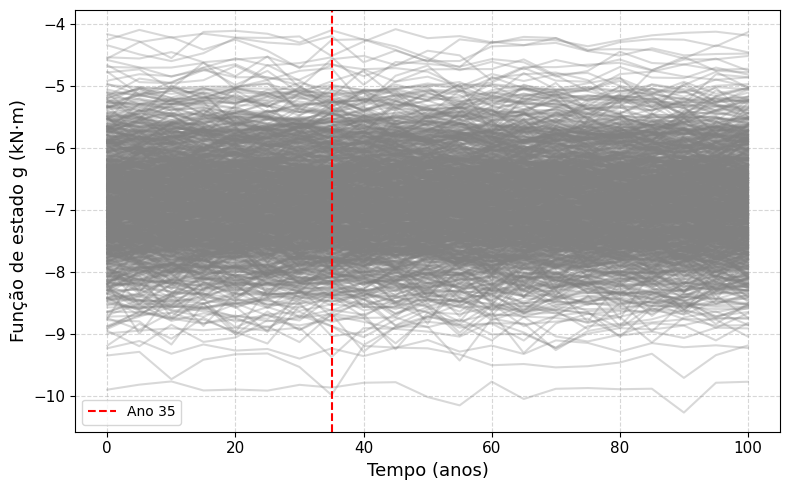

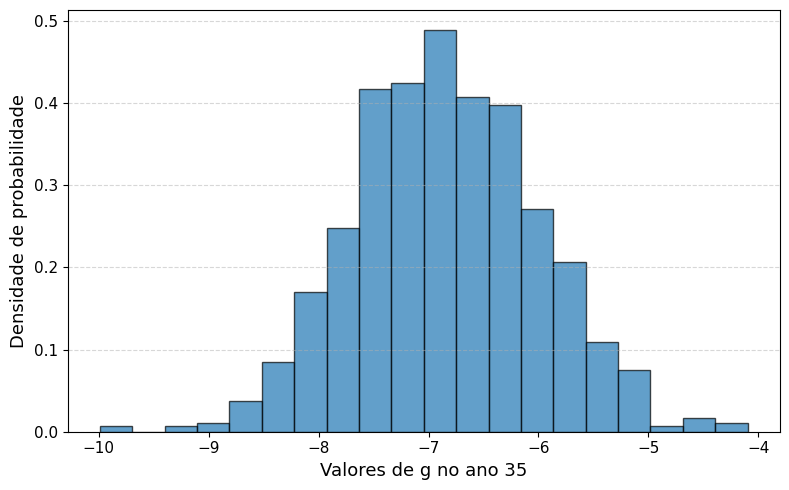

In [78]:
# ==================================
# DADOS
# ==================================
tempos_analise = tempos.copy()
curvas = results_g.copy()

if len(curvas) == 0:
    raise ValueError("Não há curvas em 'results_g'. Verifique a simulação antes de plotar.")

# Entrada do usuário
ano_escolhido = 35
if ano_escolhido < 0 or ano_escolhido > 100:
    raise ValueError("O ano deve estar entre 0 e 100.")

# Calcular valores de g no ano escolhido (interpolação linear)
g_no_ano = [np.interp(ano_escolhido, tempos_analise, g) for g in curvas]

# Informações gerais
print(f"Total de curvas no conjunto: {len(curvas)}")
print(f"Total de curvas no ano {ano_escolhido}: {len(g_no_ano)}")

# ==================================
# GRÁFICO DAS CURVAS COM LINHA VERTICAL
# ==================================
plt.figure(figsize=config_grafico["figsize"])
for g in curvas:
    plt.plot(tempos_analise, g, color=config_grafico["cor_curva"], alpha=config_grafico["alpha_curva"])
plt.axvline(x=ano_escolhido, color=config_grafico["cor_vertical"], linestyle='--', label=f"Ano {ano_escolhido}")
plt.xlabel("Tempo (anos)", fontsize=config_grafico["fonte_label"])
plt.ylabel("Função de estado g (kN·m)", fontsize=config_grafico["fonte_label"])
plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==================================
# HISTOGRAMA DOS VALORES DE g NO ANO ESCOLHIDO
# ==================================
plt.figure(figsize=config_grafico["figsize"])
plt.hist(g_no_ano, bins=20, edgecolor='black', alpha=0.7, density=True)
plt.xlabel(f"Valores de g no ano {ano_escolhido}", fontsize=config_grafico["fonte_label"])
plt.ylabel("Densidade de probabilidade", fontsize=config_grafico["fonte_label"])
plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


GRÁFICO DE DEGRADAÇÃO DO AÇO

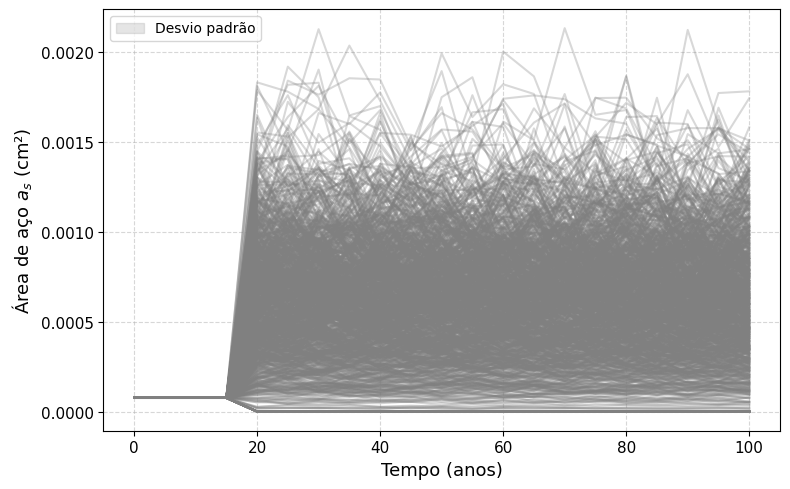

In [81]:
# ==================================
# DADOS
# ==================================
tempos_analise = tempos.copy()
areas_aco = np.array(results_as)  # Converter lista para array (simulações x tempos)

# Calcular média e desvio padrão da área de aço em cada passo de tempo
media_as = np.mean(areas_aco, axis=0)
std_as = np.std(areas_aco, axis=0)

# ==================================
# PLOTAGEM
# ==================================
plt.figure(figsize=config_grafico["figsize"])

# Curvas individuais
for a_s_curve in areas_aco:
    plt.plot(tempos_analise, a_s_curve, color=config_grafico["cor_curva"], alpha=config_grafico["alpha_curva"])

# Sombra de desvio padrão
plt.fill_between(
    tempos_analise,
    media_as - std_as,
    media_as + std_as,
    color=config_grafico["cor_curva"],
    alpha=0.2,
    label="Desvio padrão"
)

# Formatação
plt.xlabel("Tempo (anos)", fontsize=config_grafico["fonte_label"])
plt.ylabel("Área de aço $a_s$ (cm²)", fontsize=config_grafico["fonte_label"])
plt.tick_params(axis='both', labelsize=config_grafico["fonte_tick"])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Mostrar gráfico
plt.show()

